In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_main = pd.read_csv('1.Processed.csv', index_col=0)

cols = ['IDNL', 'Sex', 'Age', 'Height', 'Weight', 'BMI',
        'SBP', 'DBP', 'Heart_rate', 'Smoking', 'Alcohol', 
        'Physical_activity', 'Healthy_diet', 'Obesity', 
        'Hypertension_known', 'Hypertension_treated', 
        'Hyperlipidemia', 'Diabetes_known', 'Diabetes_treated',
        'CVD_known', 'CVD_treated', 'Stroke_history', 
        'MI_history', 'Other_CVD']
df_main.columns = cols

df_main

,IDNL,Sex,Age,Height,Weight,BMI,SBP,DBP,Heart_rate,Smoking,...,Hypertension_known,Hypertension_treated,Hyperlipidemia,Diabetes_known,Diabetes_treated,CVD_known,CVD_treated,Stroke_history,MI_history,Other_CVD
0,50001,1,4,12.0,155.0,53.5,22.268470,73.0,93.0,41,...,0,0,0,0,0,1,0,0,0,0
1,50002,0,6,15.0,176.0,64.0,20.661157,72.0,100.0,25,...,1,0,0,0,0,1,0,0,0,0
2,50003,2,6,20.0,167.0,62.0,22.230987,79.0,106.0,32,...,0,0,0,0,0,1,0,0,0,0
3,50004,1,6,18.0,172.0,97.8,33.058410,100.0,102.0,37,...,0,0,0,0,0,1,0,0,0,0
4,50006,1,3,11.0,155.0,74.0,30.801249,101.0,108.0,53,...,1,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2117,55410,0,5,14.0,173.0,66.2,22.119015,72.0,103.0,30,...,0,0,0,0,0,1,0,0,0,0
2118,55411,0,6,15.0,170.0,70.0,24.221453,68.0,105.0,36,...,0,0,0,0,0,1,0,0,0,0
2119,55412,1,4,15.0,163.5,61.1,22.856288,67.0,96.0,60,...,0,1,0,0,0,1,0,0,0,0
2120,55413,2,2,12.0,160.0,89.4,34.921875,101.0,110.0,63,...,0,1,0,0,0,0,1,0,0,0


In [3]:
# --- Загрузка целевых переменных ---
df_disease = pd.read_csv('6_Disease_info.csv', index_col=0)

# Найдём нужные столбцы 
disease_cols = df_disease.columns.tolist()
print("\nСтолбцы в Disease_info:", disease_cols)  

# нужные столбцы:
# - Инсульт: 'Disease_stroke'
# - Инфаркт: 'Disease_myocardial_infarction'
# - Диабет: 'Disease_diabetes'

target_map = {
    'Disease_stroke': 'Stroke',
    'Disease_myocardial_infarction': 'Infarct',
    'Disease_diabetes': 'Diabetes'
}

# Проверим, есть ли эти столбцы
available_targets = {}

for src, dst in target_map.items():
    if src in df_disease.columns:
        available_targets[dst] = df_disease[src]
    else:
        print(f"⚠️ Столбец {src} не найден в Disease_info.csv")


Столбцы в Disease_info: ['IDNL', 'Disease_1', 'Disease_2', 'Disease_3', 'Disease_4', 'Disease_5', 'Disease_relatives_diabetes1', 'Disease_relatives_diabetes2', 'Disease_AP1', 'Disease_AP2', 'Disease_AP3', 'Disease_osteochondrosis', 'Disease_rheumatoid_arthritis', 'Disease_chronical_bronchitis', 'Disease_bronchial_asthma', 'Disease_stroke', 'Disease_myocardial_infarction', 'Disease_ischemic_heart_disease', 'Disease_heart_rhythm_disorder', 'Disease_other_heart_diseases', 'Disease_gastrointestinal', 'Disease_gastric', 'Disease_kidney', 'Disease_thyroid_gland', 'Disease_parkinson', 'Disease_organ_transplantation', 'Disease_oncological', 'Disease_diabetes', 'Disease_diabetes_type', 'Disease_sugar_level', 'Disease_sugar_drugs', 'Disease_sugar_drugs_name1', 'Disease_sugar_drugs_name2', 'Disease_sugar_drugs_name3', 'Disease_cholesterol', 'Disease_increased_cholesterol', 'Disease_cholesterol_drugs', 'Disease_cholesterol_drugs_name', 'Disease_headache', 'Disease_headache_doctor', 'Disease_heada

In [4]:
df = df_main.copy()

for target_name, series in available_targets.items():
    df[target_name] = series

# Кодируем "Да" → 1, "Нет"/"Не знаю" → 0
for col in ['Stroke', 'Infarct', 'Diabetes']:
    if col in df.columns:
        df[col] = df[col].map({'Да': 1, 'Нет': 0, 'Не знаю': 0})

print("\nЦелевые переменные после кодирования:")
for col in ['Stroke', 'Infarct', 'Diabetes']:
    if col in df.columns:
        print(f"{col}: {df[col].value_counts().to_dict()}")


Целевые переменные после кодирования:
Stroke: {0: 2062, 1: 60}
Infarct: {0: 2055, 1: 67}
Diabetes: {0: 2006, 1: 116}


In [5]:
df = df.dropna(subset=[col for col in ['Stroke', 'Infarct', 'Diabetes'] if col in df.columns])

feature_cols = [c for c in df.columns if c not in ['IDNL', 'Stroke', 'Infarct', 'Diabetes']]
X = df[feature_cols]
y_diabetes = df['Diabetes']
y_stroke = df['Stroke']
y_infarct = df['Infarct']

print(f"\nПризнаков: {X.shape[1]}")
print(f"Объектов: {X.shape[0]}")


Признаков: 23
Объектов: 2122


In [ ]:
Теперь смотрим распределение целевой переменной, балланс классов 

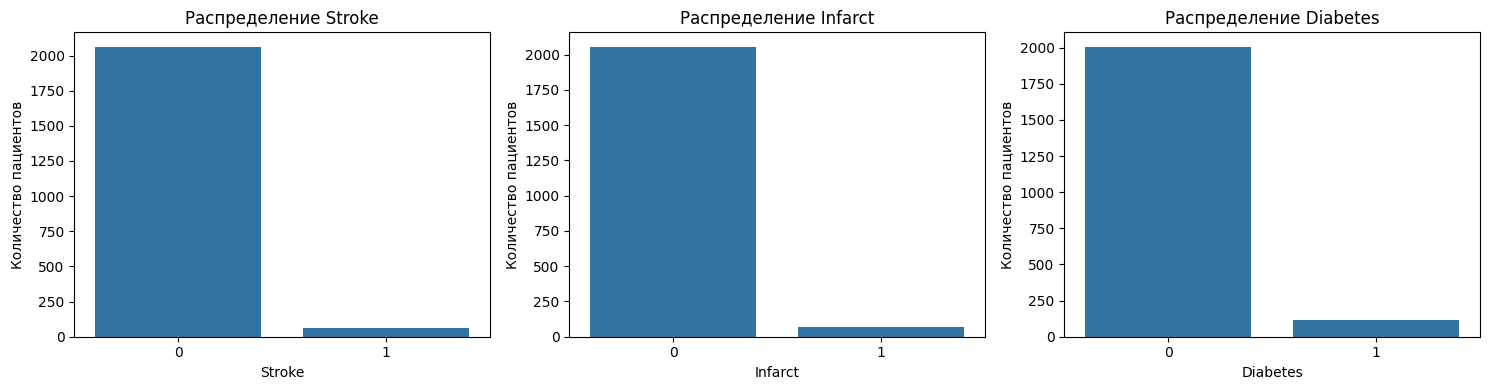

In [7]:
# --- Распределение целевых переменных ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, target in enumerate(['Stroke', 'Infarct', 'Diabetes']):
    if target in df.columns:
        sns.countplot(data=df, x=target, ax=axes[i])
        axes[i].set_title(f'Распределение {target}')
        axes[i].set_xlabel(target)
        axes[i].set_ylabel('Количество пациентов')

plt.tight_layout()
plt.show()

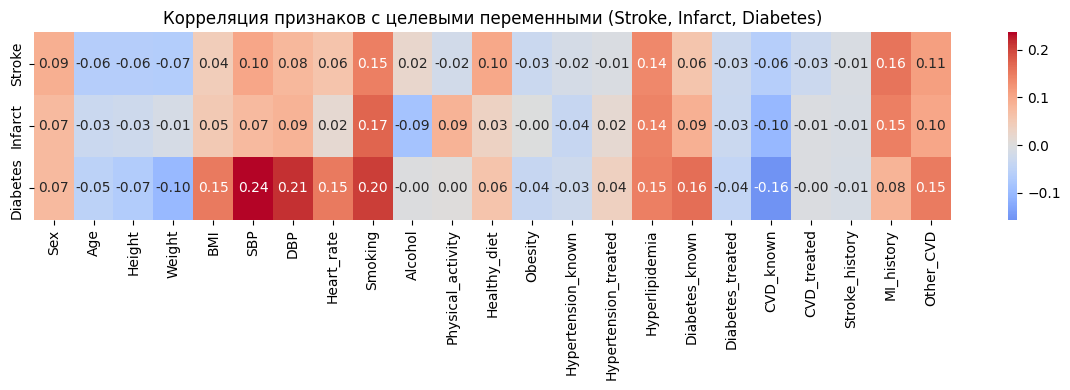

In [25]:
# --- Heatmap корреляций и топ-10 признаков ---
target_cols = ['Stroke', 'Infarct', 'Diabetes']
feature_cols = [c for c in df.columns if c not in ['IDNL'] + target_cols]
subset = df[feature_cols + target_cols].dropna()

# Считаем корреляции
corr_matrix = subset.corr()

# Выделяем только корреляции с целевыми переменными
target_corr = corr_matrix.loc[feature_cols, target_cols].round(3)

# Визуализируем heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(
    target_corr.T, 
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    cbar=True
)
plt.title('Корреляция признаков с целевыми переменными (Stroke, Infarct, Diabetes)')
plt.tight_layout()
plt.show()

In [26]:
# --- Топ-10 признаков, коррелирующих с каждой целевой переменной ---
correlations = {}
for target in target_cols:
    if target in target_corr.columns:
        # Сортируем по абсолютному значению корреляции
        corr = target_corr[target].abs().sort_values(ascending=False)
        correlations[target] = corr.head(10)

# Выводим результат
for target, top_features in correlations.items():
    print(f"\nТоп-10 признаков, наиболее коррелирующих с {target} (по модулю):")
    print(top_features)


Топ-10 признаков, наиболее коррелирующих с Stroke (по модулю):
MI_history        0.157
Smoking           0.146
Hyperlipidemia    0.137
Other_CVD         0.111
SBP               0.102
Healthy_diet      0.100
Sex               0.092
DBP               0.078
Weight            0.065
Age               0.063
Name: Stroke, dtype: float64

Топ-10 признаков, наиболее коррелирующих с Infarct (по модулю):
Smoking              0.173
MI_history           0.146
Hyperlipidemia       0.144
CVD_known            0.103
Other_CVD            0.102
Diabetes_known       0.090
DBP                  0.085
Physical_activity    0.085
Alcohol              0.085
SBP                  0.075
Name: Infarct, dtype: float64

Топ-10 признаков, наиболее коррелирующих с Diabetes (по модулю):
SBP               0.236
DBP               0.214
Smoking           0.204
Diabetes_known    0.164
CVD_known         0.156
Heart_rate        0.152
BMI               0.152
Other_CVD         0.150
Hyperlipidemia    0.147
Weight            0.

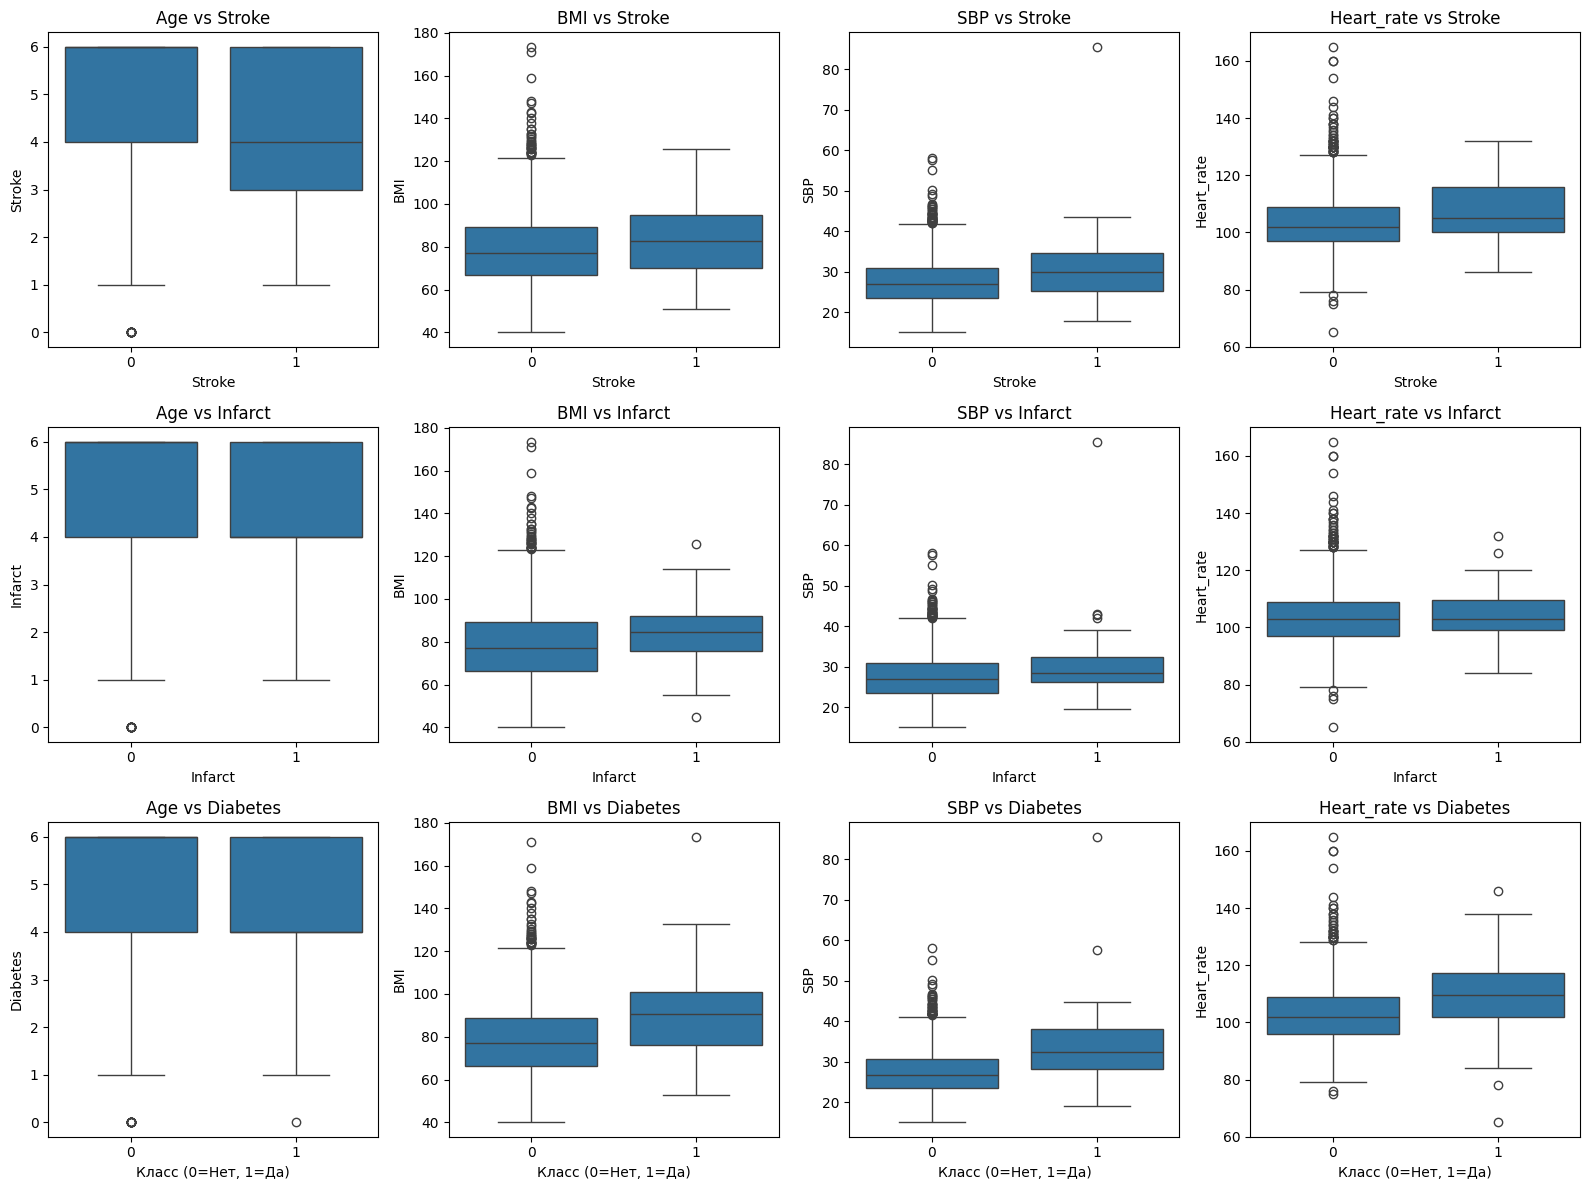

In [23]:
# --- Визуализация распределений ключевых признаков по классам ---
# Показываем медиану, квартили и выбросы ключевых признаков для классов "0" и "1".
key_features = ['Age', 'BMI', 'SBP', 'Heart_rate']

# Создаём сетку графиков: 3 строки (по числу заболеваний), 4 столбца (по числу ключевых признаков)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, target in enumerate(target_cols):
    for j, feat in enumerate(key_features):
        if feat not in df.columns or target not in df.columns:
            continue

        # Boxplot: распределение признака по классам (0/1)
        sns.boxplot(data=df, x=target, y=feat, ax=axes[i, j])
        axes[i, j].set_title(f'{feat} vs {target}')

for i in range(3):
    axes[i, 0].set_ylabel(target_cols[i])

for j in range(4):
    axes[2, j].set_xlabel('Класс (0=Нет, 1=Да)')

plt.tight_layout()
plt.show()

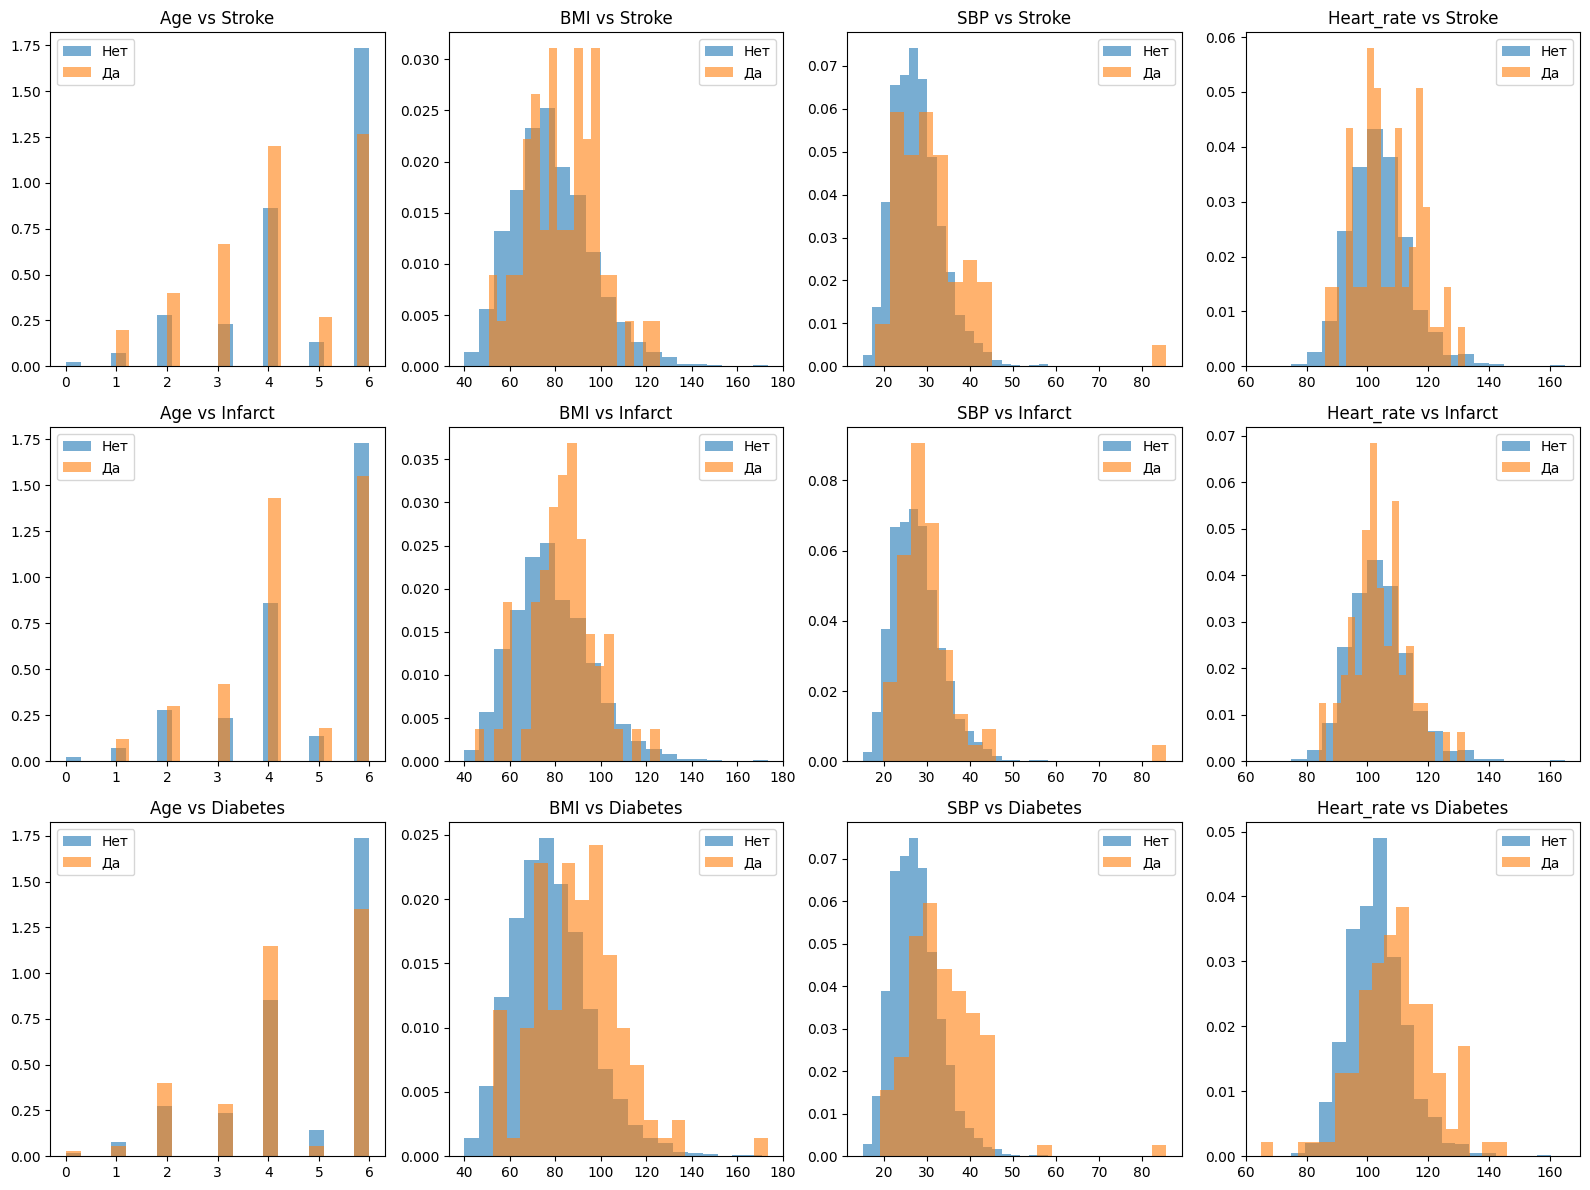

In [24]:
# --- Гистограммы для ключевых признаков по классам ---
# Это может дать больше информации о распределении (например, смещена ли она в сторону больных)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, target in enumerate(target_cols):
    for j, feat in enumerate(key_features):
        if feat not in df.columns or target not in df.columns:
            continue

        # Разделим данные на "0" и "1"
        data_0 = df[df[target] == 0][feat].dropna()
        data_1 = df[df[target] == 1][feat].dropna()

        # Гистограммы
        axes[i, j].hist(data_0, bins=20, alpha=0.6, label='Нет', density=True)
        axes[i, j].hist(data_1, bins=20, alpha=0.6, label='Да', density=True)
        axes[i, j].set_title(f'{feat} vs {target}')
        axes[i, j].legend()

plt.tight_layout()
plt.show()


--- Модель: Logistic Regression ---
AUC для Diabetes: 0.849
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       402
           1       0.00      0.00      0.00        23

    accuracy                           0.94       425
   macro avg       0.47      0.50      0.48       425
weighted avg       0.89      0.94      0.92       425

AUC для Stroke: 0.762
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       413
           1       1.00      0.08      0.15        12

    accuracy                           0.97       425
   macro avg       0.99      0.54      0.57       425
weighted avg       0.97      0.97      0.96       425

AUC для Infarct: 0.832
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       412
           1       0.00      0.00      0.00        13

    accuracy                           0.97       425
   macro avg       0.4

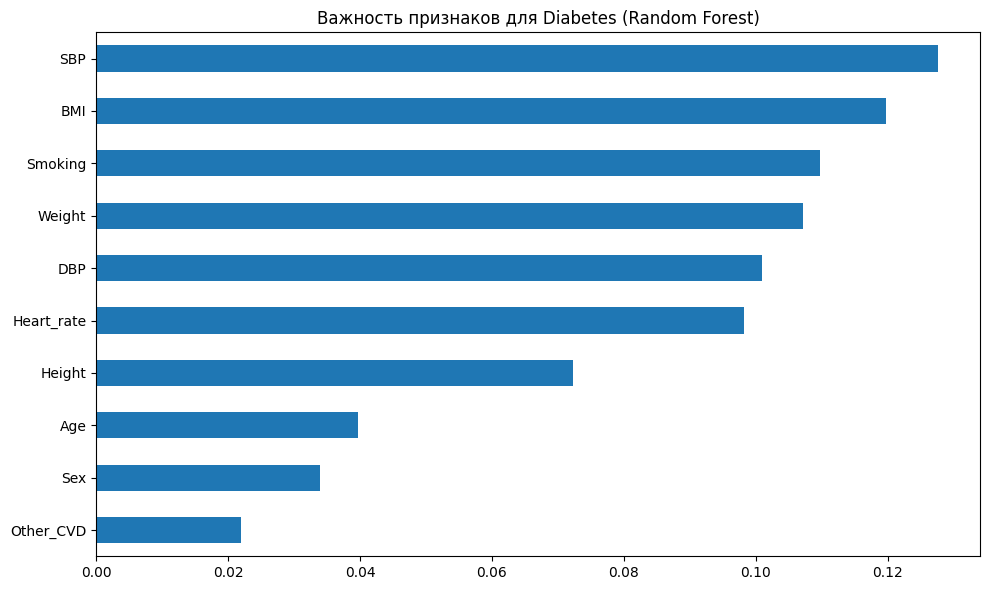

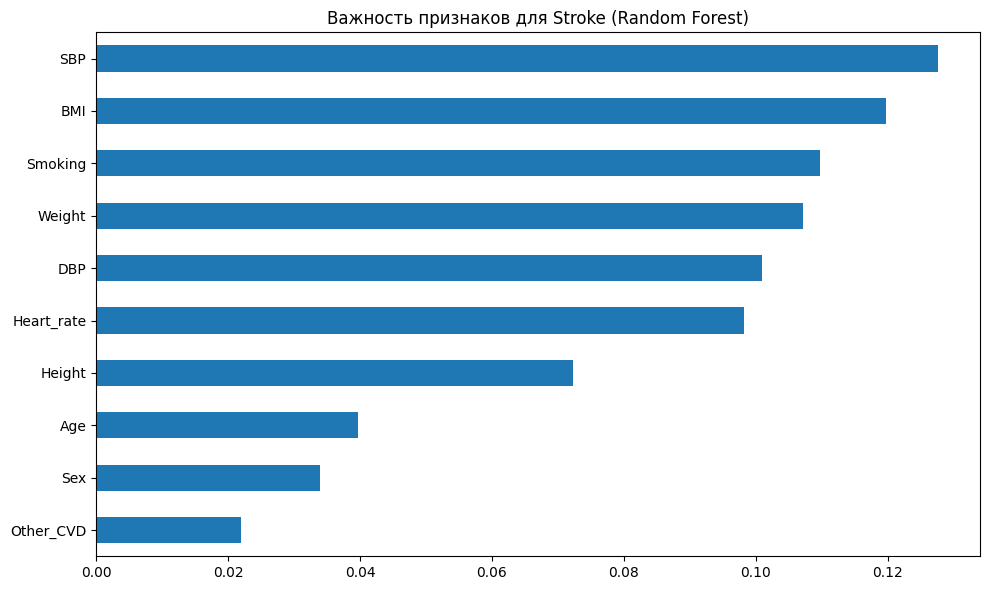

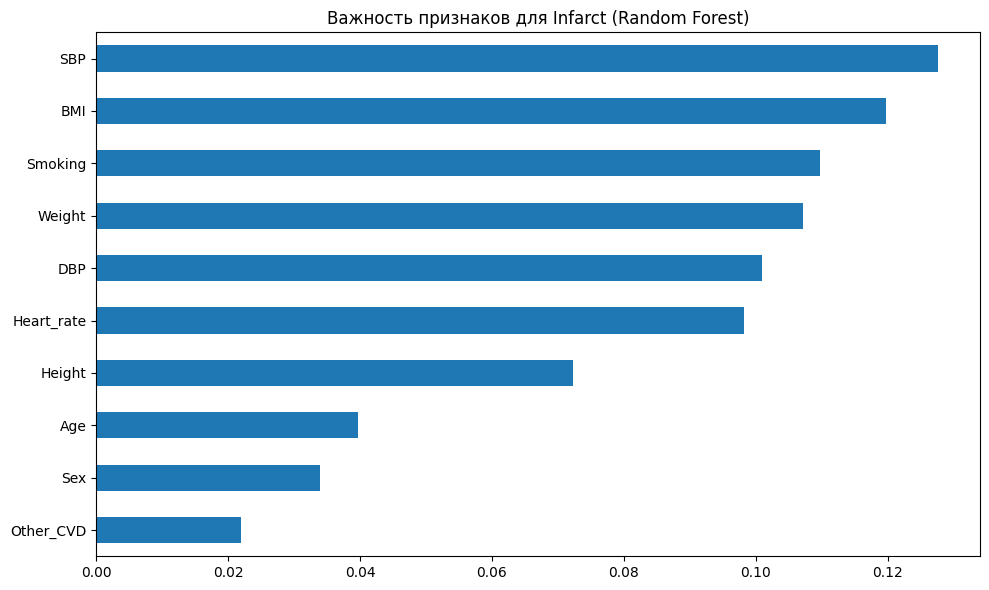

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Подготовка данных ---
target_cols = ['Stroke', 'Infarct', 'Diabetes']
feature_cols = [c for c in df.columns if c not in ['IDNL'] + target_cols]

X = df[feature_cols]
y_diabetes = df['Diabetes']
y_stroke = df['Stroke']
y_infarct = df['Infarct']

# --- Разделение на train/test ---
X_train, X_test, y_d_train, y_d_test = train_test_split(X, y_diabetes, test_size=0.2, random_state=42, stratify=y_diabetes)
X_train_s, X_test_s, y_s_train, y_s_test = train_test_split(X, y_stroke, test_size=0.2, random_state=42, stratify=y_stroke)
X_train_i, X_test_i, y_i_train, y_i_test = train_test_split(X, y_infarct, test_size=0.2, random_state=42, stratify=y_infarct)

# --- Обучение моделей ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n--- Модель: {name} ---")

    # --- 1. Диабет ---
    model_d = model.fit(X_train, y_d_train)
    y_d_pred = model_d.predict(X_test)
    y_d_proba = model_d.predict_proba(X_test)[:, 1]
    auc_d = roc_auc_score(y_d_test, y_d_proba)
    results['Diabetes'] = {'model': model_d, 'auc': auc_d}
    print(f"AUC для Diabetes: {auc_d:.3f}")
    print(classification_report(y_d_test, y_d_pred))

    # --- 2. Инсульт ---
    model_s = model.fit(X_train_s, y_s_train)
    y_s_pred = model_s.predict(X_test_s)
    y_s_proba = model_s.predict_proba(X_test_s)[:, 1]
    auc_s = roc_auc_score(y_s_test, y_s_proba)
    results['Stroke'] = {'model': model_s, 'auc': auc_s}
    print(f"AUC для Stroke: {auc_s:.3f}")
    print(classification_report(y_s_test, y_s_pred))

    # --- 3. Инфаркт ---
    model_i = model.fit(X_train_i, y_i_train)
    y_i_pred = model_i.predict(X_test_i)
    y_i_proba = model_i.predict_proba(X_test_i)[:, 1]
    auc_i = roc_auc_score(y_i_test, y_i_proba)
    results['Infarct'] = {'model': model_i, 'auc': auc_i}
    print(f"AUC для Infarct: {auc_i:.3f}")
    print(classification_report(y_i_test, y_i_pred))

# --- Визуализация важности признаков (Random Forest) ---
model_rf = models['Random Forest']

for target in ['Diabetes', 'Stroke', 'Infarct']:
    trained_model = results[target]['model']
    if hasattr(trained_model, 'feature_importances_'):
        feat_importances = pd.Series(trained_model.feature_importances_, index=feature_cols).sort_values(key=abs, ascending=False)
        
        plt.figure(figsize=(10, 6))
        feat_importances.head(10).plot(kind='barh')
        plt.title(f'Важность признаков для {target} (Random Forest)')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

In [6]:
"""
# --- 1. Импорт библиотек ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# --- 2. Загрузка основного датасета ---
df_main = pd.read_csv('1.Processed.csv', index_col=0)

# Переименуем столбцы для ясности (на основе логики из ноутбуков)
cols = ['IDNL', 'Sex', 'Age', 'Height', 'Weight', 'BMI',
        'SBP', 'DBP', 'Heart_rate', 'Smoking', 'Alcohol', 
        'Physical_activity', 'Healthy_diet', 'Obesity', 
        'Hypertension_known', 'Hypertension_treated', 
        'Hyperlipidemia', 'Diabetes_known', 'Diabetes_treated',
        'CVD_known', 'CVD_treated', 'Stroke_history', 
        'MI_history', 'Other_CVD']
df_main.columns = cols

print("Форма основного датасета:", df_main.shape)
print("\nОсновной датасет")
print(df_main)

# --- 3. Загрузка целевых переменных ---
df_disease = pd.read_csv('6_Disease_info.csv', index_col=0)

# Найдём нужные столбцы (порядок может отличаться — проверим имена)
disease_cols = df_disease.columns.tolist()
print("\nСтолбцы в Disease_info:", disease_cols)  # покажем первые 10

# По логике из Pasted_Text — нужные столбцы:
# - Инсульт: 'Disease_stroke'
# - Инфаркт: 'Disease_myocardial_infarction'
# - Диабет: 'Disease_diabetes'

target_map = {
    'Disease_stroke': 'Stroke',
    'Disease_myocardial_infarction': 'Infarct',
    'Disease_diabetes': 'Diabetes'
}

# Проверим, есть ли эти столбцы
available_targets = {}
for src, dst in target_map.items():
    if src in df_disease.columns:
        available_targets[dst] = df_disease[src]
    else:
        print(f"⚠️ Столбец {src} не найден в Disease_info.csv")

# --- 4. Объединение и кодирование ---
df = df_main.copy()
for target_name, series in available_targets.items():
    df[target_name] = series

# Кодируем "Да" → 1, "Нет"/"Не знаю" → 0
for col in ['Stroke', 'Infarct', 'Diabetes']:
    if col in df.columns:
        df[col] = df[col].map({'Да': 1, 'Нет': 0, 'Не знаю': 0})

print("\nЦелевые переменные после кодирования:")
for col in ['Stroke', 'Infarct', 'Diabetes']:
    if col in df.columns:
        print(f"{col}: {df[col].value_counts().to_dict()}")

# Удалим строки, где целевые переменные NaN
df = df.dropna(subset=[col for col in ['Stroke', 'Infarct', 'Diabetes'] if col in df.columns])

# --- 5. Подготовка признаков ---
feature_cols = [c for c in df.columns if c not in ['IDNL', 'Stroke', 'Infarct', 'Diabetes']]
X = df[feature_cols]
y_diabetes = df['Diabetes']
y_stroke = df['Stroke']
y_infarct = df['Infarct']

print(f"\nПризнаков: {X.shape[1]}")
print(f"Объектов: {X.shape[0]}")

# --- Распределение целевых переменных ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, target in enumerate(['Stroke', 'Infarct', 'Diabetes']):
    if target in df.columns:
        sns.countplot(data=df, x=target, ax=axes[i])
        axes[i].set_title(f'Распределение {target}')
        axes[i].set_xlabel(target)
        axes[i].set_ylabel('Количество пациентов')

plt.tight_layout()
plt.show()

# --- Heatmap корреляций и топ-10 признаков ---
target_cols = ['Stroke', 'Infarct', 'Diabetes']
feature_cols = [c for c in df.columns if c not in ['IDNL'] + target_cols]
subset = df[feature_cols + target_cols].dropna()

# Считаем корреляции
corr_matrix = subset.corr()

# Выделяем только корреляции с целевыми переменными
target_corr = corr_matrix.loc[feature_cols, target_cols].round(3)

# Визуализируем heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(
    target_corr.T, 
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    cbar=True
)
plt.title('Корреляция признаков с целевыми переменными (Stroke, Infarct, Diabetes)')
plt.tight_layout()
plt.show()

# --- Топ-10 признаков, коррелирующих с каждой целевой переменной ---
correlations = {}
for target in target_cols:
    if target in target_corr.columns:
        # Сортируем по абсолютному значению корреляции
        corr = target_corr[target].abs().sort_values(ascending=False)
        correlations[target] = corr.head(10)

# Выводим результат
for target, top_features in correlations.items():
    print(f"\nТоп-10 признаков, наиболее коррелирующих с {target} (по модулю):")
    print(top_features)
    
# --- Визуализация распределений ключевых признаков по классам ---
# Показываем медиану, квартили и выбросы ключевых признаков для классов "0" и "1".
key_features = ['Age', 'BMI', 'SBP', 'Heart_rate']

# Создаём сетку графиков: 3 строки (по числу заболеваний), 4 столбца (по числу ключевых признаков)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, target in enumerate(target_cols):
    for j, feat in enumerate(key_features):
        if feat not in df.columns or target not in df.columns:
            continue

        # Boxplot: распределение признака по классам (0/1)
        sns.boxplot(data=df, x=target, y=feat, ax=axes[i, j])
        axes[i, j].set_title(f'{feat} vs {target}')

for i in range(3):
    axes[i, 0].set_ylabel(target_cols[i])

for j in range(4):
    axes[2, j].set_xlabel('Класс (0=Нет, 1=Да)')

plt.tight_layout()
plt.show()

# --- Гистограммы для ключевых признаков по классам ---
# Это может дать больше информации о распределении (например, смещена ли она в сторону больных)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, target in enumerate(target_cols):
    for j, feat in enumerate(key_features):
        if feat not in df.columns or target not in df.columns:
            continue

        # Разделим данные на "0" и "1"
        data_0 = df[df[target] == 0][feat].dropna()
        data_1 = df[df[target] == 1][feat].dropna()

        # Гистограммы
        axes[i, j].hist(data_0, bins=20, alpha=0.6, label='Нет', density=True)
        axes[i, j].hist(data_1, bins=20, alpha=0.6, label='Да', density=True)
        axes[i, j].set_title(f'{feat} vs {target}')
        axes[i, j].legend()

plt.tight_layout()
plt.show()

SyntaxError: incomplete input (3684050433.py, line 1)